## c2 w1 p3

### Linear Regression

* Linear Regression là một thuật toán đơn giản giải quyết bài toán regression.
    ```
    * training set: "input features (X_train)" và "target output (Y_train)"
    -> đưa vào
    * learning algorithm
    -> trả về
    * model function (f)
    ```

* Model function f sau learning thể hiện sự tương quan giữa input và correct output, nên nó có thể dùng để dự đoán các data points mới.
    ```
    new input (X) -> model function (f) -> prediction output (Y_hat)
    ```

* Function của thuật toán Linear Regression là Linear Function. Với bài toán LR one variable, mô hình tương ứng còn được gọi là  
**Univariate Linear Function**. Còn với bài toán LR nhiều biến, nó được gọi là **Multivariate Linear Function**.
    $$
    f_{w,b}(x) = wx + b
    $$
    - Parameters:
        - $w$: weight(s)  
        - $b$: bias
        - m: số phần tử trong training set

#### Problem: House Price Prediction

* Bài toán dự đoán giá nhà (1000s of dollars) dựa trên kích thước (1000 sqft).

    |Size (1000 sqft)|Price (1000s of dollars)|
    |-|-|
    |1.0|300|
    |2.0|500|

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300, 500])

print(x_train)
print(y_train)

[1. 2.]
[300 500]


In [3]:
m = x_train.shape[0]
print(m)

2


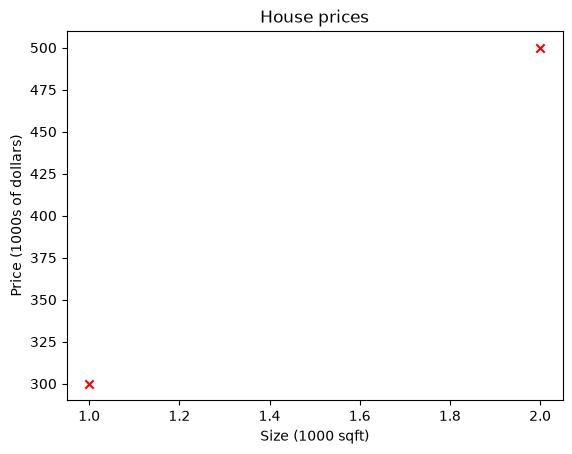

In [4]:
plt.scatter(x_train, y_train, c='r', marker='x')

plt.title("House prices")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")
plt.show()

* Univariate Linear Function:
    $$
    f_{w,b} = wx + b
    $$
    - $w$: weight
    - $b$: bias

In [5]:
def compute_ulf(w, b, x):
    y_predict = w * x + b
    return y_predict

In [6]:
w = 180
b = 110

y_predict = compute_ulf(w, b, x_train)
print(y_predict)

[290. 470.]


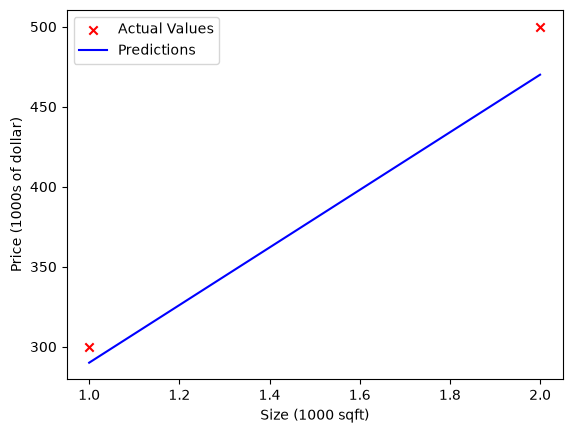

In [7]:
plt.figure()
plt.scatter(x_train, y_train, c='red', marker='x', label='Actual Values')
plt.plot(x_train, y_predict, c='b', label="Predictions")

plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (1000s of dollar)")
plt.legend()

plt.show()

In [8]:
x_new = 1.4

y_predict = compute_ulf(w, b, x_new)
print(f"{x_new} -> {y_predict}")

1.4 -> 362.0


### Cost function

* Trong Linear Regression model $f_{w,b}(x) = wx + b$, 2 parameters chính là weight (w) và bias (b). Trong đó:
    - b (y-intercept) thể hiện "độ cao" của đồ thị
    - w thể hiện độ nghiêng (slope) của đồ thị  

=> Trong không gian 2d, 3d thậm chí cao hơn, đồ thị được biểu hiện là 1 hyperplane, và luôn được định hình theo 2 tác nhân trên.

(Phân biệt parameters, coefficients, weights, intercept, bias, ...)

* Linear model đã được fit bởi training data sẽ đưa các dự đoán của mình. Để xác định mức độ chính xác cuả mô hình vừa tạo, ta tiến hành tính toán sai lệch giữa correct answer (y) và prediction (y_hat). Một function tính toán error đơn giản, hiệu quả mà vẫn vô cùng phổ biến là Square Error Cost Function:
    $$
    J(w,b)  = \frac{1}{2m}\sum_{i=1}^m(\hat{y}^{(i)} - y^{(i)})^2
    $$

* Square Error Cost Function for Univariate Linear Function
    $$
    J(w,b)  = \frac{1}{2m}\sum_{i=1}^m(f_{w,b}(x^{(i)}) - y^{(i)})^2
    $$

* Theo đó, bài toán dự đoán giá trị sẽ trở thành, lựa chọn các tham số phù hợp để tối thiểu giá trị của cost function
    $$
        \min_{w,b} J(w,b)
    $$

* **SUMMARY:**    
    * MODEL: Linear Regression Model 
        $f_{w,b}(x) = wx + b$

    * PARAMETERS: $w$, $b$

    * COST FUNCTION: Square Error Cost Function
        $J(w,b)  = \frac{1}{2m}\sum_{i=1}^m(\hat{y}^{(i)} - y^{(i)})^2$

    * GOAL: 
        $\underset{w,b}{\operatorname{minimize}} J(w,b)$
        <!-- $\min_{w,b} J(w,b)$ -->

* Why square the error?  
Squaring makes the cost more sensitive to large errors, causing large errors to contribute disproportionately to the cost and gradient.

* Tuỳ vào cost function, sẽ xuất hiện nhiều điểm "đáy" khác nhau, các điểm này được gọi là local minima, trong số các local minama, điểm "sâu nhất" được gọi là global minima.

* Đối với MSE cost function, đồ thị cost luôn xuất hiện và chỉ xuất hiện 1 local minima duy nhất, cũng là global minima của cost.
    - Với đồ thị 2 chiều (1 chiều param và 1 chiều cost) là 1 đường cong hướng lên
    - Với đồ thị 3 chiều (2 chiều params) là hình soup-bowl hay hammock
    - Suy ra đối với các trường hợp nhiều chiều hơn...

=> Đặc tính này quan trọng đối với thuật toán tìm kiếm min cost (đáy vùng trũng) sau này. Và MSE cost functuon còn được gọi là convex function.

#### Computing Cost Function

|set|values|
|--|--|
|X - Size (1000 sqft) |1.0, 1.7, 2.0, 2.5, 3.0, 3.2|
|Y - Price (1000s of dollars) |250, 300, 480,  430,   630, 730|

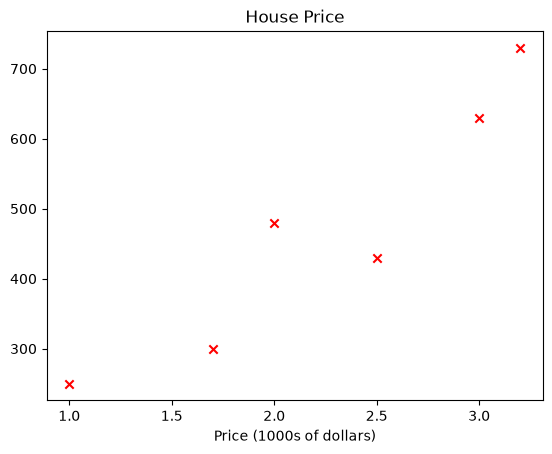

In [9]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730])

plt.figure()
plt.scatter(x_train, y_train, c='r', marker='x')

plt.xlabel("Size (1000 sqft)")
plt.xlabel("Price (1000s of dollars)")
plt.title("House Price")

plt.show()

In [10]:
def compute_cost_MSE(x, y, w, b):
    m = x.shape[0]
    f = x * w + b
    sum_square_error = ((f - y)**2).sum()
    cost = (1 / (2 * m)) * sum_square_error

    return cost

In [ ]:
# Ideals params are w = 209 and b = 2.4
w = 209
b = 2.4
mse = compute_cost_MSE(x_train, y_train, w, b)
print(mse)

1736.2683333333327


Chọn b = 2.4, ta vẽ thử đồ thị cost function theo sự thay đổi của w từ 150 đến 250, bước 10.

In [12]:
w_range = np.arange(170, 230 + 1, 10)
mse_values = np.array([compute_cost_MSE(x_train, y_train, w, b) for w in w_range])
print([f"{mse:.2f}" for mse in mse_values])

['6047.91', '4135.68', '2779.78', '1980.21', '1736.98', '2050.08', '2919.51']


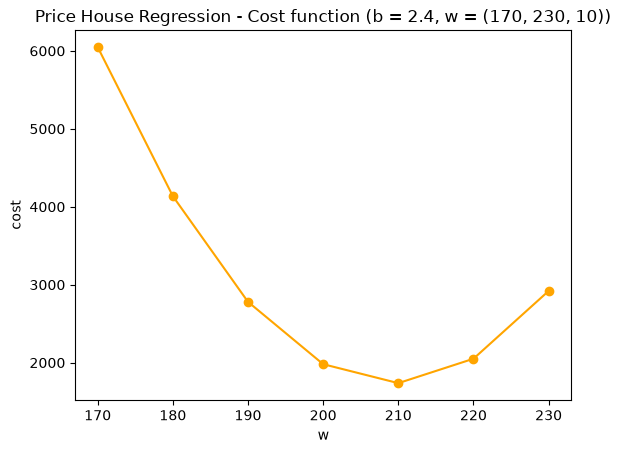

In [22]:
plt.figure()
plt.plot(w_range, mse_values, marker='o', c='orange')

plt.title("Price House Regression - Cost function (b = 2.4, w = (170, 230, 10))")
plt.xlabel("w")
plt.ylabel("cost")

plt.show()